# Environment Setup

In [1]:
import os
from pathlib import Path

WORKING_DIRECTORY = Path.cwd().parents[0]
os.chdir(WORKING_DIRECTORY)

# Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Data

The data units for the prices is Euros per MWh (€/MWh).

In [3]:
DATA_PATH = Path("data")
DATA_FILE = 'electricity_dah_prices.csv'
data_file_path = DATA_PATH.joinpath(DATA_FILE)
print(f'data file path: {data_file_path}')

data file path: data/electricity_dah_prices.csv


In [4]:
data = pd.read_csv(data_file_path)
data.head()

,date,hour,france,italy,belgium,spain,uk,germany
0,2022/01/01,00:00 - 01:00,89.06,170.28,82.02,145.86,0.27,50.05
1,2022/01/01,01:00 - 02:00,78.48,155.72,67.07,114.90,-0.01,41.33
2,2022/01/01,02:00 - 03:00,85.16,147.09,75.11,113.87,0.27,43.22
3,2022/01/01,03:00 - 04:00,50.00,91.00,50.91,97.80,-0.01,45.46
4,2022/01/01,04:00 - 05:00,37.67,104.00,37.67,97.80,-0.01,37.67


In [5]:
def process_hours(df):
    hours = df['hour'].str.split('-', expand=True)
    df['start_hour'] = hours[0].str.strip()
    df['end_hour'] = hours[1].str.strip()
    return df

data = (
    data
    .pipe(process_hours)
    .assign(
        start_hour = lambda x: pd.to_datetime(x['start_hour'], format='%H:%M').dt.time,
        end_hour   = lambda x: pd.to_datetime(x['end_hour'], format='%H:%M').dt.time,
        date       = lambda x: pd.to_datetime(x['date']),
        datetime   = lambda x: x.apply(lambda row: pd.Timestamp.combine(row['date'], row['start_hour']), axis=1)
    )
)

data.head()

,date,hour,france,italy,belgium,spain,uk,germany,start_hour,end_hour,datetime
0,2022-01-01,00:00 - 01:00,89.06,170.28,82.02,145.86,0.27,50.05,00:00:00,01:00:00,2022-01-01 00:00:00
1,2022-01-01,01:00 - 02:00,78.48,155.72,67.07,114.90,-0.01,41.33,01:00:00,02:00:00,2022-01-01 01:00:00
2,2022-01-01,02:00 - 03:00,85.16,147.09,75.11,113.87,0.27,43.22,02:00:00,03:00:00,2022-01-01 02:00:00
3,2022-01-01,03:00 - 04:00,50.00,91.00,50.91,97.80,-0.01,45.46,03:00:00,04:00:00,2022-01-01 03:00:00
4,2022-01-01,04:00 - 05:00,37.67,104.00,37.67,97.80,-0.01,37.67,04:00:00,05:00:00,2022-01-01 04:00:00


# Data Checks

## Null values

In [6]:
data.isnull().sum()

date             0
hour             0
france           1
italy            1
belgium          1
spain            1
uk            1442
germany          1
start_hour       0
end_hour         0
datetime         0
dtype: int64

### Overall null

In [7]:
# Hypothesis: The missing 1 value happens at the same time for all the countries, which could indicate a data collection issue at that specific time point.
countries_of_interest = ['spain', 'france', 'italy', 'belgium', 'germany']
data[data[countries_of_interest].isnull().any(axis=1)]

,date,hour,france,italy,belgium,spain,uk,germany,start_hour,end_hour,datetime
2042,2022-03-27,02:00 - 03:00,NaN,NaN,NaN,NaN,NaN,NaN,02:00:00,03:00:00,2022-03-27 02:00:00


The hypothesis is true. I have found out the 2022-03-27 the time was changed from 02:00 AM to 03:00 AM. Therefore, the value is missing. Actually, the price value at 02:00 AM should be the same as at 03:00 AM

In [8]:
time_change_index = data[data[countries_of_interest].isnull().any(axis=1)].index[0]
data.iloc[time_change_index] = data.iloc[time_change_index - 1]
data.isnull().sum()

date             0
hour             0
france           0
italy            0
belgium          0
spain            0
uk            1441
germany          0
start_hour       0
end_hour         0
datetime         0
dtype: int64

### UK

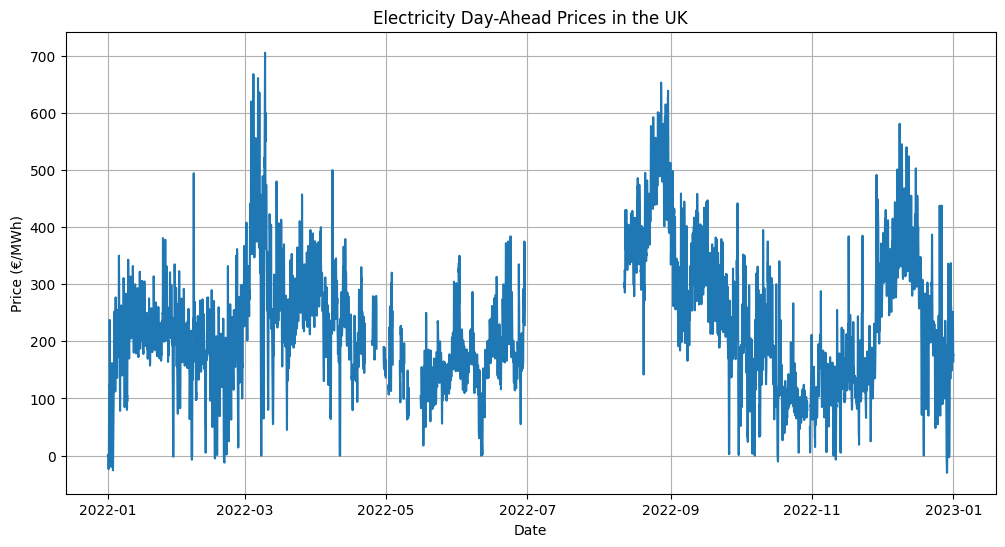

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(data['datetime'], data['uk'])
plt.grid()
plt.xlabel('Date')
plt.ylabel('Price (€/MWh)')
plt.title('Electricity Day-Ahead Prices in the UK')
plt.show()

In [10]:
data[data['uk'].isna()].copy()

,date,hour,france,italy,belgium,spain,uk,germany,start_hour,end_hour,datetime
2664,2022-04-22,00:00 - 01:00,216.06,217.65,185.08,216.06,NaN,191.07,00:00:00,01:00:00,2022-04-22 00:00:00
2665,2022-04-22,01:00 - 02:00,190.91,206.27,180.70,200.00,NaN,183.93,01:00:00,02:00:00,2022-04-22 01:00:00
2666,2022-04-22,02:00 - 03:00,187.01,199.20,187.01,187.01,NaN,187.01,02:00:00,03:00:00,2022-04-22 02:00:00
2667,2022-04-22,03:00 - 04:00,179.41,199.02,179.41,179.41,NaN,179.41,03:00:00,04:00:00,2022-04-22 03:00:00
2668,2022-04-22,04:00 - 05:00,176.09,203.22,176.09,176.09,NaN,176.09,04:00:00,05:00:00,2022-04-22 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...
7268,2022-10-30,19:00 - 20:00,165.00,165.00,165.00,200.00,NaN,165.00,19:00:00,20:00:00,2022-10-30 19:00:00
7269,2022-10-30,20:00 - 21:00,147.52,147.52,147.52,225.35,NaN,147.52,20:00:00,21:00:00,2022-10-30 20:00:00
7270,2022-10-30,21:00 - 22:00,139.08,139.08,138.92,209.27,NaN,138.96,21:00:00,22:00:00,2022-10-30 21:00:00
7271,2022-10-30,22:00 - 23:00,127.00,119.99,127.00,157.31,NaN,127.00,22:00:00,23:00:00,2022-10-30 22:00:00


In [11]:
uk_missing = data[data['uk'].isna()].copy()
uk_missing['period'] = (uk_missing.index.to_series().diff().fillna(1) != 1).cumsum()

missing_periods = (
    uk_missing
    .groupby('period')['datetime']
    .agg(start='min', end='max')
    .reset_index(drop=True)
)
missing_periods['duration_hours'] = (
    (missing_periods['end'] - missing_periods['start']).dt.total_seconds() / 3600 + 1
).astype(int)

missing_periods

,start,end,duration_hours
0,2022-04-22,2022-04-24 23:00:00,72
1,2022-04-27,2022-04-29 23:00:00,72
2,2022-05-01,2022-05-01 23:00:00,24
3,2022-05-04,2022-05-06 23:00:00,72
4,2022-05-09,2022-05-09 23:00:00,24
5,2022-05-11,2022-05-15 23:00:00,120
6,2022-06-30,2022-08-11 23:00:00,1032
7,2022-10-30,2022-10-30 23:00:00,24


# Plots

In [12]:
COUNTRIES = ['france', 'italy', 'belgium', 'spain', 'uk', 'germany']
print(f'countries: {COUNTRIES}')

countries: ['france', 'italy', 'belgium', 'spain', 'uk', 'germany']


## Overall

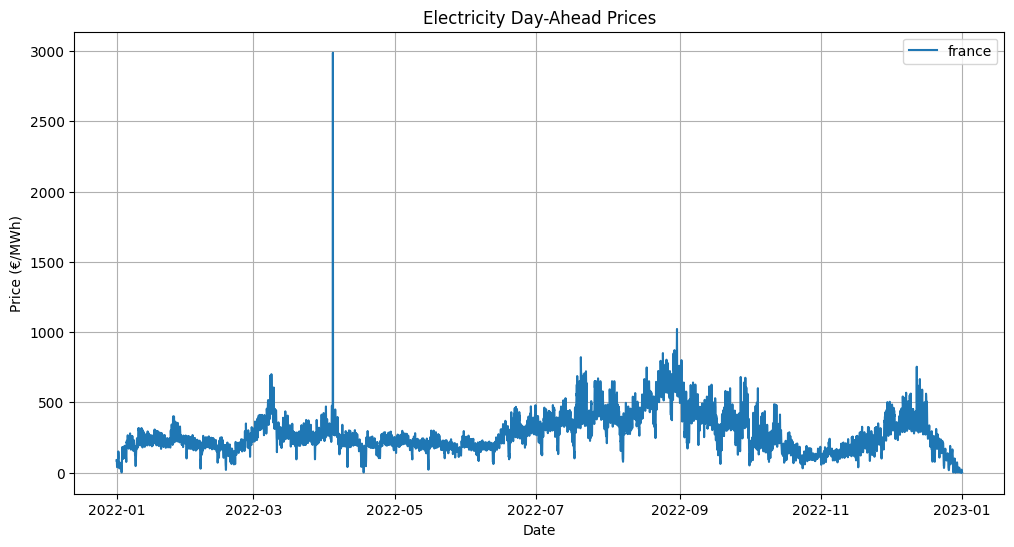

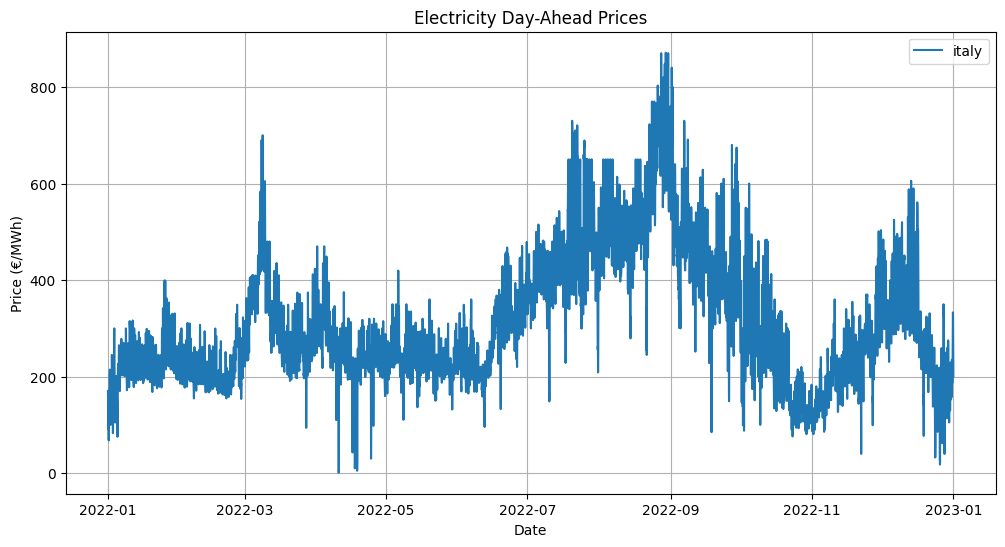

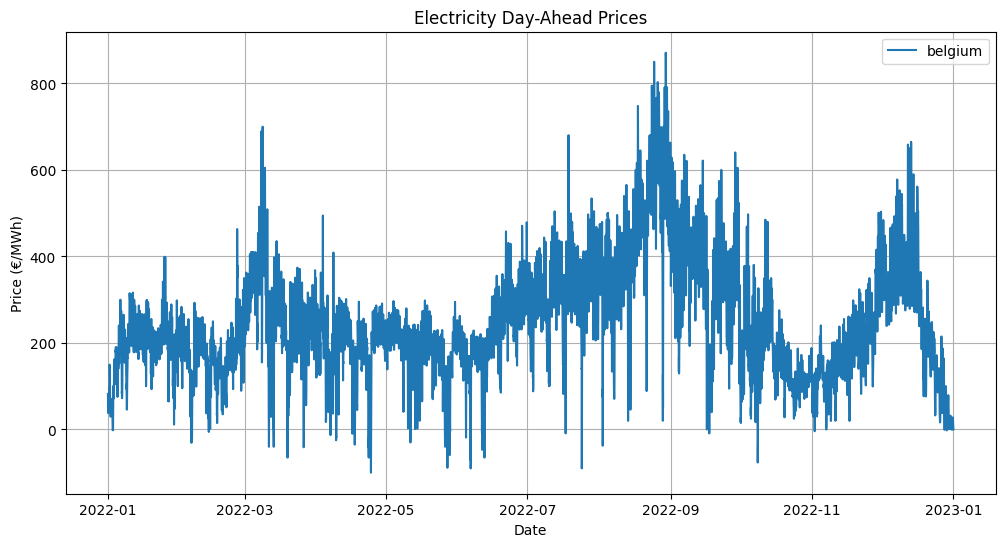

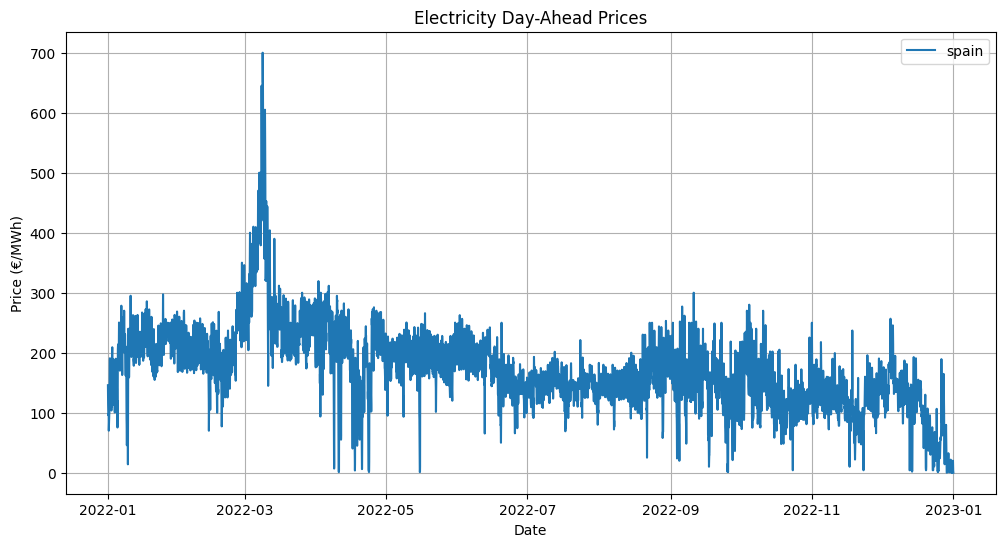

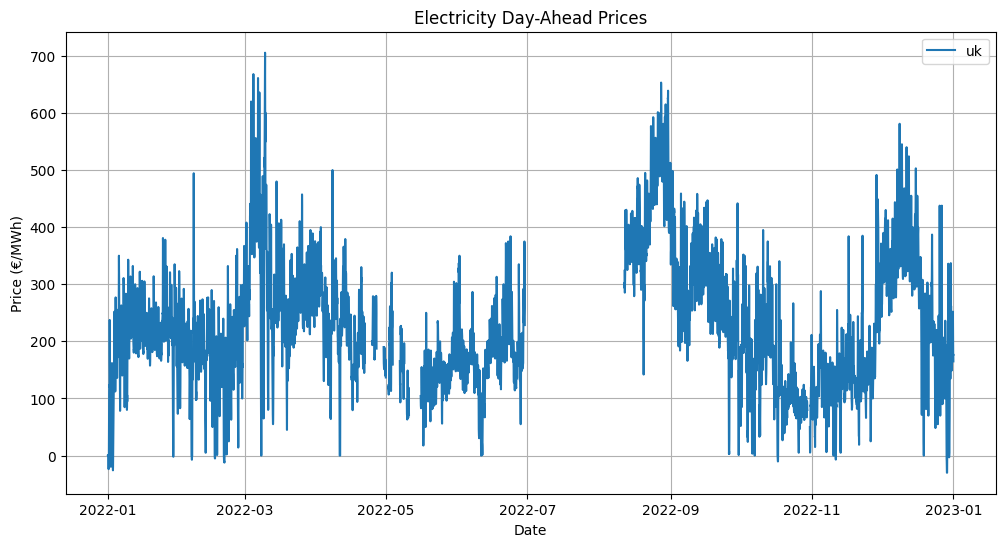

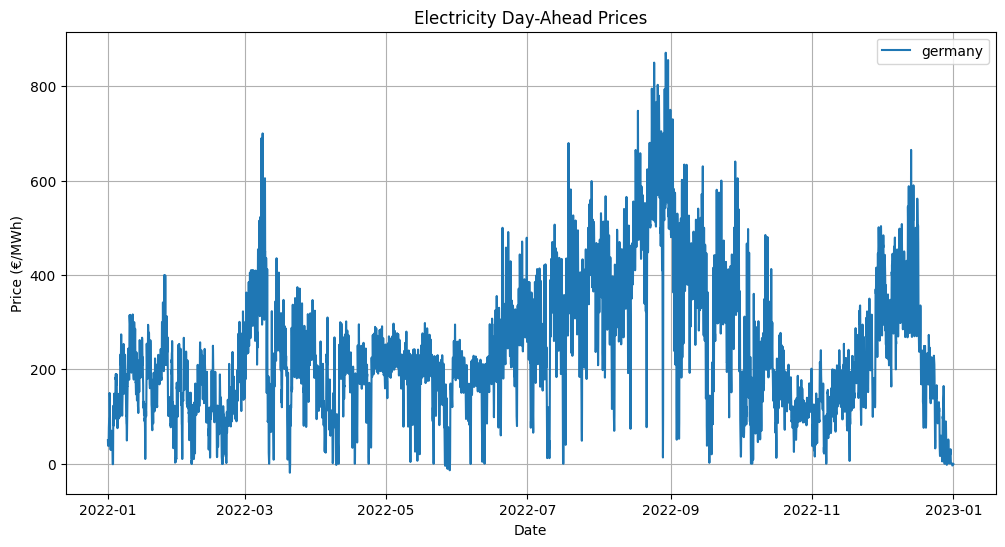

In [13]:
for country in COUNTRIES:
    plt.figure(figsize=(12, 6))
    plt.plot(data['datetime'], data[country], label=country)
    plt.grid()
    plt.legend()
    plt.xlabel('Date')
    plt.ylabel('Price (€/MWh)')
    plt.title('Electricity Day-Ahead Prices')
    plt.show()

## Histograms

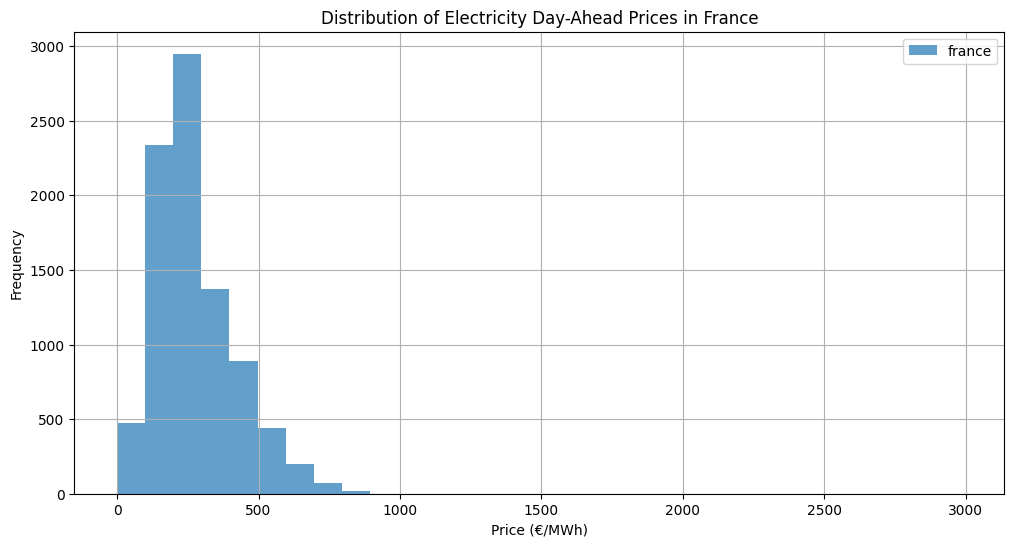

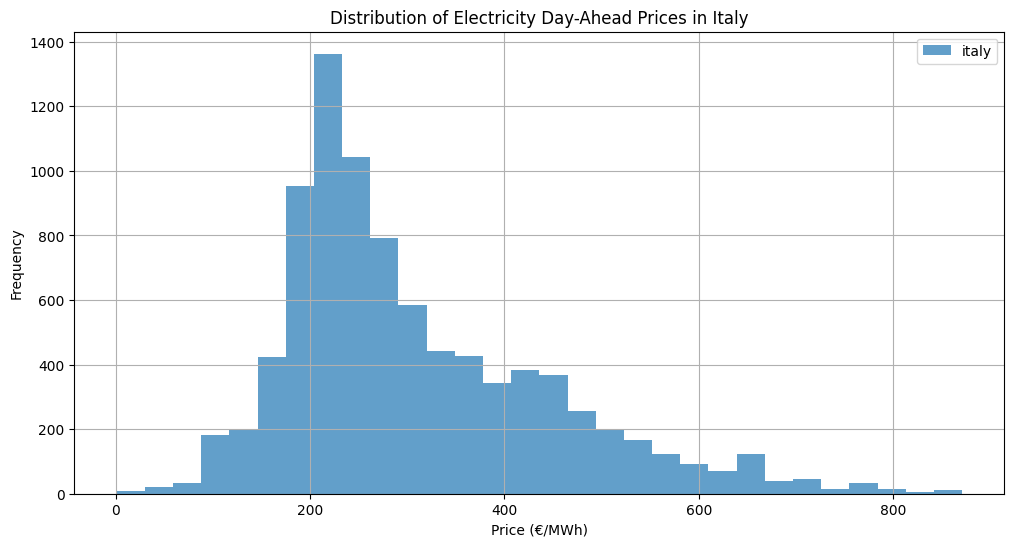

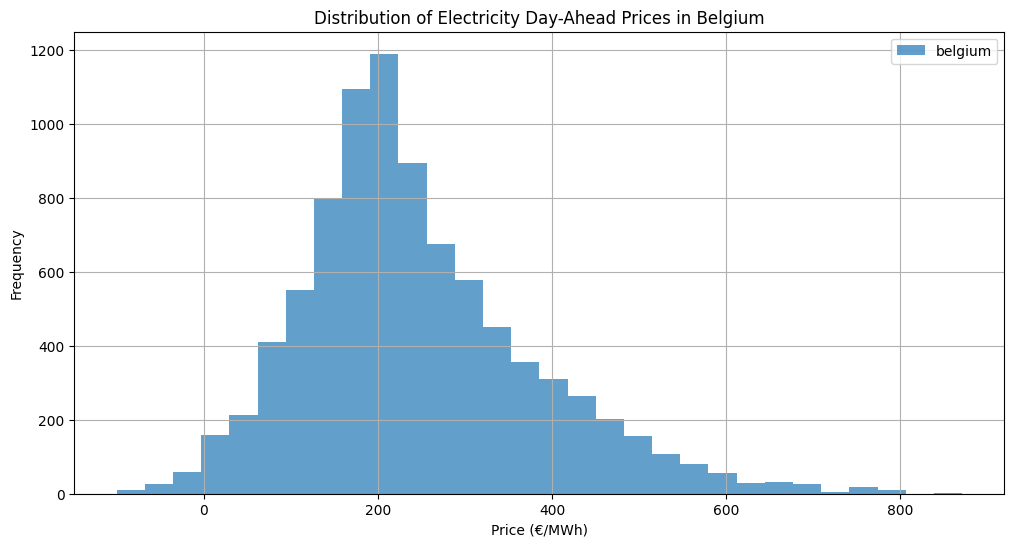

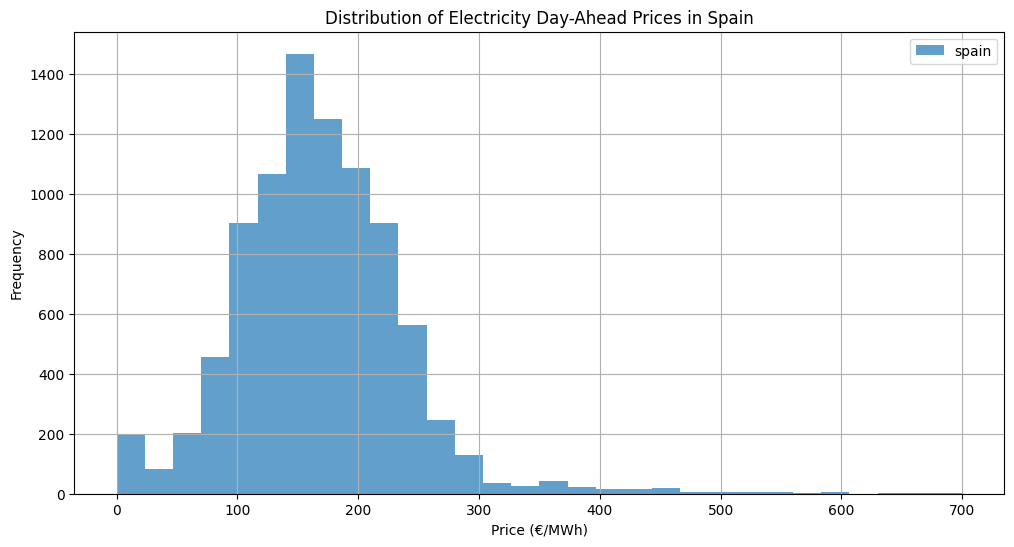

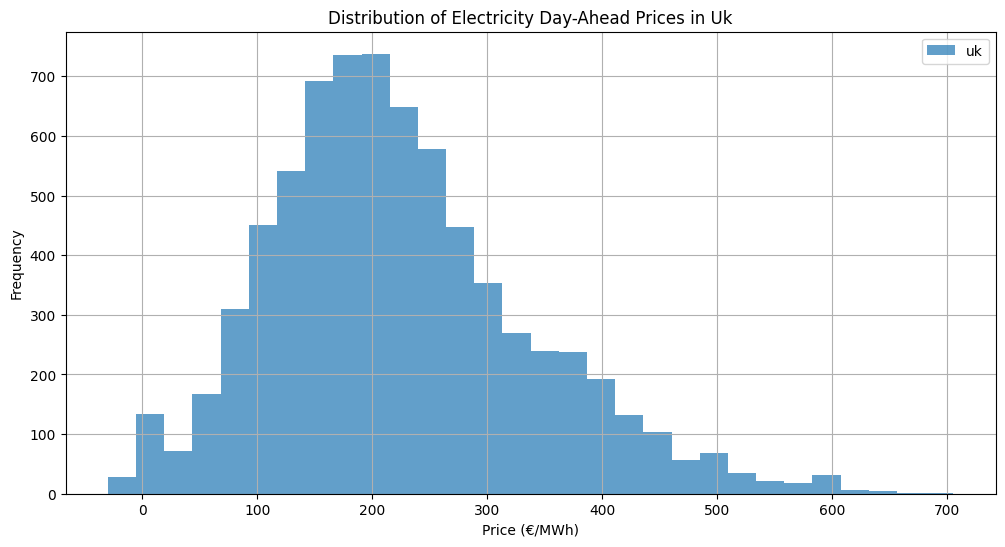

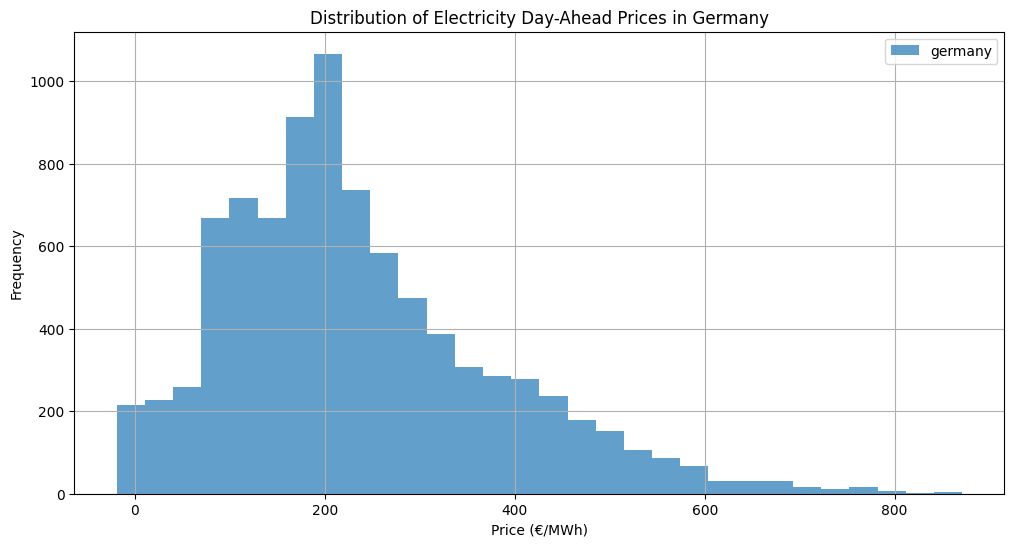

In [14]:
for country in COUNTRIES:
    plt.figure(figsize=(12, 6))
    plt.hist(data[country], bins=30, label=country, alpha=0.7)
    plt.grid()
    plt.legend()
    plt.xlabel('Price (€/MWh)')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of Electricity Day-Ahead Prices in {country.capitalize()}')
    plt.show()

# Outliers

France has an evident outlier:

In [15]:
data[data['france'] == data['france'].max()]

,date,hour,france,italy,belgium,spain,uk,germany,start_hour,end_hour,datetime
2240,2022-04-04,08:00 - 09:00,2987.78,470.0,230.0,286.08,209.72,101.16,08:00:00,09:00:00,2022-04-04 08:00:00


That was actually an outlier and a real value at the same time, as there was an explanation for that price according to the French grid regulator:

*The price increase observed on 4 April 2022 was the result of an exceptional combination of different events: the
night of 4 April was the coldest for an April since 1947; import capacities were low before the daily auction, and
were even exceptionally low from Germany and Belgium; EDF announced the unexpected unavailability of the Dam-
pierre 1 nuclear unit, when nuclear availability was already exceptionally low; wind generation during the critical
hours of 7am - 9am was underestimated, as was the production of combined heat and power (CHP) plants; the
mechanisms for managing peak consumption in France end on 31 March and were therefore not available on 4
April (capacity mechanism, TEMPO tariffs, calls for demand-response tenders, etc.).
In addition, several generation facilities started their maintenance at the end of March and were no longer available;
and the RTE's alerts probably led market players prudently to seek a long position, which might have increased the
daily auction price.
The combination of these factors led to extremely high prices on 4 April 2022 for 7am and 8am (€2,720/MWh and
€2,990/MWh respectively). These prices would have been approximately halved with a small shift in the supply/de-
mand balance of between 500 and 1000 MW (increase in generation, decrease in consumption).
At this stage of its analyses, the CRE has not detected any abnormal or suspicious behaviour during the day-ahead
auction itself.*

Source: https://www.cre.fr/fileadmin/Documents/Rapports_et_etudes/import/Rapport_pic_prix_4avril2022-en.pdf

As it is just one data point out of 8761 (<0.1%) I will keep the value in the dataset.

# Next Steps

- Recommended Approach: LightGBM with Lag Features
- Why: Electricity day-ahead forecasting is typically a 24-hour-ahead prediction task. The dataset is too small (~8K rows) to benefit much from deep learning, but it has rich temporal structure ideal for gradient boosting on engineered features.

- Feature engineering plan:
    - Calendar features: hour-of-day, day-of-week, month, is-weekend, is-holiday
    - Lag features: price at t-24h, t-48h, t-168h (same hour yesterday, day before, last week)
    - Rolling statistics: 24h/168h rolling mean and std
    - Cross-country features: other countries' prices as covariates (since markets are correlated)

- Suggested Progression
    1. Baseline: Prophet or SARIMA — fast to set up, gives you a benchmark
    1. Main model: LightGBM with lag + calendar features — likely best accuracy/effort tradeoff
    1. Stretch goal: If you add external data (temperature, renewable output, demand), a Temporal Fusion Transformer becomes competitive